In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
%matplotlib inline

In [2]:
pwd

'/Users/zeleninam2/Documents/1_projects/hitop/all_code/HiTOP'

In [3]:
data_dir = Path('logs/logs_final/logs_icc/')

In [9]:
full_scales = pd.read_csv(data_dir / 'result_ICC_origscales_forplot_mostcombined_indecivinessenriched.csv')
cores = pd.read_csv(data_dir / 'result_ICC_invariantonly_combined.csv')

In [10]:
full_scales

,Measure,Type,Description,ICC,F,df1,df2,pval,CI95,lci,uci
0,hitop_sum,ICC2,Single random raters,0.9271,26.4575,433,433,0,[0.91 0.94],0.91,0.94
1,baars_sum,ICC2,Single random raters,0.8890,16.9922,433,433,0,[0.87 0.91],0.87,0.91
2,phq_sum,ICC2,Single random raters,0.8967,18.3703,433,433,0,[0.88 0.91],0.88,0.91
3,gad_sum,ICC2,Single random raters,0.8596,13.2185,433,433,0,[0.83 0.88],0.83,0.88
4,baars_inattention_sum,ICC2,Single random raters,0.8688,14.2105,433,433,0,[0.84 0.89],0.84,0.89
5,baars_hyperactivity_sum,ICC2,Single random raters,0.7666,7.6091,433,433,0,[0.72 0.8 ],0.72,0.80
6,baars_impulsivity_sum,ICC2,Single random raters,0.8035,9.1618,433,433,0,[0.77 0.83],0.77,0.83
7,baars_sct_sum,ICC2,Single random raters,0.8729,14.7103,433,433,0,[0.85 0.89],0.85,0.89
8,hitop_anhedonic_depression,ICC2,Single random raters,0.8999,19.0399,433,433,0,[0.88 0.92],0.88,0.92
9,hitop_anxious_worry,ICC2,Single random raters,0.8849,16.3932,433,433,0,[0.86 0.9 ],0.86,0.90


In [11]:
cores

,Measure,Type,Description,ICC,F,df1,df2,pval,CI95,lci,uci
0,hitop_anhedonic_depression_invcore,ICC2,Single random raters,0.8834,16.1751,433,433,0.0,[0.86 0.9 ],0.86,0.90
1,hitop_anxious_worry_invcore,ICC2,Single random raters,0.8668,14.0354,433,433,0.0,[0.84 0.89],0.84,0.89
2,hitop_appetite_gain_invcore,ICC2,Single random raters,0.8136,9.7248,433,433,0.0,[0.78 0.84],0.78,0.84
3,hitop_separation_insecurity_invcore,ICC2,Single random raters,0.8678,14.1820,433,433,0.0,[0.84 0.89],0.84,0.89
4,hitop_situational_phobia_invcore,ICC2,Single random raters,0.7579,7.2560,433,433,0.0,[0.71 0.8 ],0.71,0.80
5,hitop_social_anxiety_invcore,ICC2,Single random raters,0.8545,12.7370,433,433,0.0,[0.83 0.88],0.83,0.88
6,hitop_well_being_invcore,ICC2,Single random raters,0.8557,12.8362,433,433,0.0,[0.83 0.88],0.83,0.88


In [12]:
cores['Measure'] = cores.Measure.str.strip('_invcore')
cores['Measure'] = cores.Measure.replace({
    'hitop_appetite_ga':'hitop_appetite_gain',
    'hitop_anhedonic_depress': 'hitop_anhedonic_depression',
})
cores

,Measure,Type,Description,ICC,F,df1,df2,pval,CI95,lci,uci
0,hitop_anhedonic_depression,ICC2,Single random raters,0.8834,16.1751,433,433,0.0,[0.86 0.9 ],0.86,0.90
1,hitop_anxious_worry,ICC2,Single random raters,0.8668,14.0354,433,433,0.0,[0.84 0.89],0.84,0.89
2,hitop_appetite_gain,ICC2,Single random raters,0.8136,9.7248,433,433,0.0,[0.78 0.84],0.78,0.84
3,hitop_separation_insecurity,ICC2,Single random raters,0.8678,14.1820,433,433,0.0,[0.84 0.89],0.84,0.89
4,hitop_situational_phobia,ICC2,Single random raters,0.7579,7.2560,433,433,0.0,[0.71 0.8 ],0.71,0.80
5,hitop_social_anxiety,ICC2,Single random raters,0.8545,12.7370,433,433,0.0,[0.83 0.88],0.83,0.88
6,hitop_well_being,ICC2,Single random raters,0.8557,12.8362,433,433,0.0,[0.83 0.88],0.83,0.88


In [13]:
iccs = full_scales.merge(cores.loc[:, ['Measure', 'ICC', 'uci', 'lci']], how='outer', on='Measure', suffixes=['_fs', '_ic'])
iccs = iccs.sort_values('ICC_fs').reset_index(drop=True)
iccs['full_scale_invariant'] = iccs.ICC_ic.isnull()
iccs

,Measure,Type,Description,ICC_fs,F,df1,df2,pval,CI95,lci_fs,uci_fs,ICC_ic,uci_ic,lci_ic,full_scale_invariant
0,hitop_indecisiveness,ICC2,Single random raters,0.7231,6.2069,254,254,0,[0.66 0.78],0.66,0.78,NaN,NaN,NaN,True
1,hitop_hyposomnia,ICC2,Single random raters,0.7595,7.3133,433,433,0,[0.72 0.8 ],0.72,0.80,NaN,NaN,NaN,True
2,baars_hyperactivity_sum,ICC2,Single random raters,0.7666,7.6091,433,433,0,[0.72 0.8 ],0.72,0.80,NaN,NaN,NaN,True
3,hitop_appetite_loss,ICC2,Single random raters,0.7842,8.2640,433,433,0,[0.75 0.82],0.75,0.82,NaN,NaN,NaN,True
4,hitop_situational_phobia,ICC2,Single random raters,0.7888,8.4554,433,433,0,[0.75 0.82],0.75,0.82,0.7579,0.80,0.71,False
5,baars_impulsivity_sum,ICC2,Single random raters,0.8035,9.1618,433,433,0,[0.77 0.83],0.77,0.83,NaN,NaN,NaN,True
6,hitop_insomnia,ICC2,Single random raters,0.8160,9.8654,433,433,0,[0.78 0.85],0.78,0.85,NaN,NaN,NaN,True
7,hitop_appetite_gain,ICC2,Single random raters,0.8199,10.0940,433,433,0,[0.79 0.85],0.79,0.85,0.8136,0.84,0.78,False
8,hitop_panic,ICC2,Single random raters,0.8423,11.6960,433,433,0,[0.81 0.87],0.81,0.87,NaN,NaN,NaN,True
9,hitop_shame_guilt,ICC2,Single random raters,0.8476,12.1027,433,433,0,[0.82 0.87],0.82,0.87,NaN,NaN,NaN,True


In [14]:
measure_dict = {
    'hitop_hyposomnia': 'Hyposomnia',
    'hitop_appetite_loss': 'Appetite Loss',
    'hitop_situational_phobia': 'Situational Phobia',
    'hitop_insomnia': 'Insomnia',
    'hitop_indecisiveness': 'Indecisiveness',
    'hitop_appetite_gain': 'Appetite Gain',
    'hitop_panic': 'Panic',
    'hitop_shame_guilt': 'Shame/Guilt',
    'hitop_well_being': 'Well Being',
    'baars_inattention_sum': 'Inattention',
    'hitop_separation_insecurity': 'Separation Insecurity',
    'hitop_cognitive_problems': 'Cognitive Problems',
    'hitop_anxious_worry': 'Anxious Worry',
    'hitop_social_anxiety': 'Social Anxiety',
    'hitop_anhedonic_depression': 'Anhedonic Depression',
    'baars_sct_sum': 'Sluggish Cognitive Tempo',
    'baars_impulsivity_sum': 'Impulsivity',
    'baars_hyperactivity_sum': 'Hyperactivity',
    'hitop_sum': 'HiTOP: Total',
    'baars_sum': 'BAARS: Total',
    'gad_sum': 'GAD-7',
    'phq_sum': 'PHQ-8',
}

order_dict = {
    'hitop_hyposomnia': 2,
    'hitop_appetite_loss': 3,
    'hitop_situational_phobia': 4,
    'hitop_insomnia': 5,
    'hitop_indecisiveness': 6,
    'hitop_appetite_gain': 7,
    'hitop_panic': 8,
    'hitop_shame_guilt': 9,
    'hitop_well_being': 10,
    'hitop_separation_insecurity': 11,
    'hitop_cognitive_problems': 12,
    'hitop_anxious_worry': 13,
    'hitop_social_anxiety': 14,
    'hitop_anhedonic_depression': 15,
    
    'baars_hyperactivity_sum': 18,
    'baars_impulsivity_sum': 19,
    'baars_inattention_sum': 20,
    'baars_sct_sum': 21,

    'gad_sum': 24,
    'baars_sum': 25,
    'phq_sum': 26,
    'hitop_sum': 27,

}

In [15]:

iccs['measure_toplot'] = iccs.Measure.replace(measure_dict)
iccs['plotting_order'] = iccs.Measure.replace(order_dict)

labels_df = pd.DataFrame(
    [{'measure_toplot': 'HiTOP Subscales', 'plotting_order':16},
     {'measure_toplot': 'BAARS Subscales', 'plotting_order':22},
    ]
)
iccs = pd.concat([iccs, labels_df])

/var/folders/d8/s1szglf95wl4_7_f5jkmn561n3477x/T/ipykernel_18969/2847084176.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  iccs['plotting_order'] = iccs.Measure.replace(order_dict)


In [16]:
iccs = iccs.sort_values('plotting_order', ascending=False).reset_index(drop=True)

In [17]:
iccs.plotting_order

0     27
1     26
2     25
3     24
4     22
5     21
6     20
7     19
8     18
9     16
10    15
11    14
12    13
13    12
14    11
15    10
16     9
17     8
18     7
19     6
20     5
21     4
22     3
23     2
Name: plotting_order, dtype: int64

Text(0.5, 0, 'ICC')

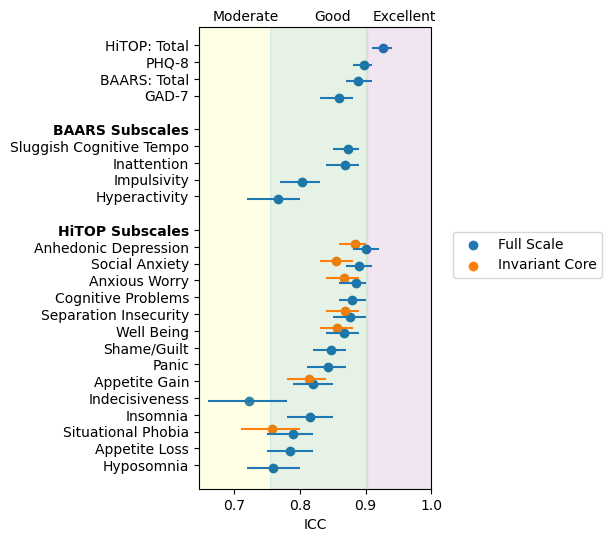

In [18]:
offset = 0.15
fig, ax = plt.subplots(1,figsize=(3,6))
ax.scatter(iccs.ICC_fs, iccs.plotting_order-offset, label='Full Scale')
ax.set_yticks(iccs.plotting_order)
ax.set_yticklabels(iccs.measure_toplot)
ax.hlines(iccs.plotting_order-offset, iccs.lci_fs, iccs.uci_fs)

ax.scatter(iccs.ICC_ic, iccs.plotting_order+offset, color=sns.color_palette()[1], label='Invariant Core')
ax.hlines(iccs.plotting_order+offset, iccs.lci_ic, iccs.uci_ic, color=sns.color_palette()[1])

ax.get_ymajorticklabels()[4].set_weight('bold')
ax.get_ymajorticklabels()[9].set_weight('bold')

ylim = ax.get_ylim()
xlim = ax.get_xlim()
ax.fill_betweenx(ylim,[0.5, 0.5] ,[0.75, 0.75], color='yellow', alpha=0.1)
ax.fill_betweenx(ylim,[0.755, 0.755] ,[0.9, 0.9], color='green', alpha=0.1)
ax.fill_betweenx(ylim,[0.902, 0.902] ,[1, 1], color='purple', alpha=0.1)


ax.set_ylim(ylim)
ax.set_xlim((xlim[0], 1))

fig.legend(loc='center left', bbox_to_anchor=(0.95, 0.5))
fig.text(0.28, 0.89, 'Moderate', ha='center')
fig.text(0.57, 0.89, 'Good', ha='center')
fig.text(0.81, 0.89, 'Excellent', ha='center')
ax.set_xlabel('ICC')

# alternative - indecisiveness on combined data

/var/folders/d8/s1szglf95wl4_7_f5jkmn561n3477x/T/ipykernel_18969/3704541912.py:8: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  iccs['plotting_order'] = iccs.Measure.replace(order_dict)


Text(0.5, 0, 'ICC')

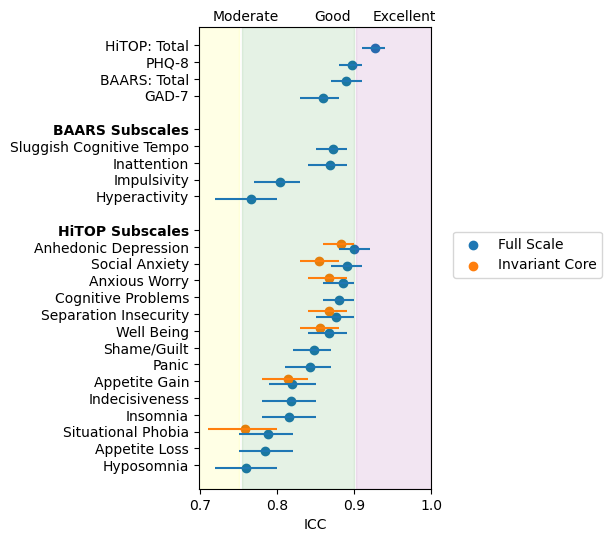

In [22]:
full_scales = pd.read_csv(data_dir / 'result_ICC_origscales_combined.csv')

iccs = full_scales.merge(cores.loc[:, ['Measure', 'ICC', 'uci', 'lci']], how='outer', on='Measure', suffixes=['_fs', '_ic'])
iccs = iccs.sort_values('ICC_fs').reset_index(drop=True)
iccs['full_scale_invariant'] = iccs.ICC_ic.isnull()

iccs['measure_toplot'] = iccs.Measure.replace(measure_dict)
iccs['plotting_order'] = iccs.Measure.replace(order_dict)

labels_df = pd.DataFrame(
    [{'measure_toplot': 'HiTOP Subscales', 'plotting_order':16},
     {'measure_toplot': 'BAARS Subscales', 'plotting_order':22},
    ]
)
iccs = pd.concat([iccs, labels_df])
iccs = iccs.sort_values('plotting_order', ascending=False).reset_index(drop=True)

offset = 0.15
fig, ax = plt.subplots(1,figsize=(3,6))
ax.scatter(iccs.ICC_fs, iccs.plotting_order-offset, label='Full Scale')
ax.set_yticks(iccs.plotting_order)
ax.set_yticklabels(iccs.measure_toplot)
ax.hlines(iccs.plotting_order-offset, iccs.lci_fs, iccs.uci_fs)

ax.scatter(iccs.ICC_ic, iccs.plotting_order+offset, color=sns.color_palette()[1], label='Invariant Core')
ax.hlines(iccs.plotting_order+offset, iccs.lci_ic, iccs.uci_ic, color=sns.color_palette()[1])

ax.get_ymajorticklabels()[4].set_weight('bold')
ax.get_ymajorticklabels()[9].set_weight('bold')

ylim = ax.get_ylim()
xlim = ax.get_xlim()
ax.fill_betweenx(ylim,[0.5, 0.5] ,[0.75, 0.75], color='yellow', alpha=0.1)
ax.fill_betweenx(ylim,[0.755, 0.755] ,[0.9, 0.9], color='green', alpha=0.1)
ax.fill_betweenx(ylim,[0.902, 0.902] ,[1, 1], color='purple', alpha=0.1)


ax.set_ylim(ylim)
ax.set_xlim((xlim[0], 1))

fig.legend(loc='center left', bbox_to_anchor=(0.95, 0.5))
fig.text(0.28, 0.89, 'Moderate', ha='center')
fig.text(0.57, 0.89, 'Good', ha='center')
fig.text(0.81, 0.89, 'Excellent', ha='center')
ax.set_xlabel('ICC')
